In [30]:
import math
import numpy as np
import pytensor
import pytensor.tensor as pt
import pandas as pd

from scipy.optimize import minimize
import matplotlib.pyplot as plt

In [31]:
def broadcast(n, A, b, v, s, tau):
    def _promote(x):
        x_var = pt.constant(x) if not hasattr(x, "ndim") else x
        if x_var.ndim == 0:return pt.repeat(x_var, n)
        if x_var.ndim == 1:return x_var
        raise ValueError(f"Scalars or 1-D tensor of dim {n} only, got ndim={x_var.ndim}")
    return (_promote(x) for x in (A, b, v, s, tau))

def LBA(rt, response, n, A, b, v, s, tau=0):
    """PDF of Linear Ballistic Accumulator model."""

    # Ensure inputs are not mangled
    A, b, v, s, tau = broadcast(n, A, b, v, s, tau)

    # Standard normal PDF and CDF
    normpdf = lambda x: pt.exp(-0.5 * x**2) / pt.sqrt(2 * math.pi)
    normcdf = lambda x: 0.5 * (1 + pt.erf(x / math.sqrt(2)))

    def tpdf(t, A, b, v, s):
        """First-passage time probability density function for single accumulator."""
        g = (b - A - t * v) / (t * s)
        h = (b - t * v) / (t * s)
        
        # First-passage density formula
        pdf = (1/A) * (-v * normcdf(g) + s * normpdf(g) + v * normcdf(h) - s * normpdf(h))

        return pt.maximum(pdf, 1e-20)  # Numerical stability

    def tcdf(t, A, b, v, s):
        """First-passage time cumulative distribution function for single accumulator."""
        
        # Calculate standardized variables
        g = (b - A - t * v) / (t * s)
        h = (b - t * v) / (t * s)
        
        # CDF components
        p1 = ((b - A - t * v) / A) * normcdf(g)
        p2 = ((b - t * v) / A) * normcdf(h)
        p3 = ((t * s) / A) * normpdf(g)
        p4 = ((t * s) / A) * normpdf(h)
        
        cdf = 1 + p1 - p2 + p3 - p4

        # Ensure CDF is between 0 and 1
        return pt.clip(cdf, 1e-20, 1 - 1e-20)
    
    # First‐passage densities for each accumulator
    f = pt.stack([ tpdf(rt - tau[i], A[i], b[i], v[i], s[i]) for i in range(n)], axis=0) # shape (m, n_trials)
    F = pt.stack([tcdf(rt - tau[i], A[i], b[i], v[i], s[i]) for i in range(n)], axis=0) # CDFs for each accumulator
    p_zero = pt.prod(normcdf(-v / s)) # Probability that none ever finish

    # For each i: f_i * ∏_{j≠i} (1 − F_j)
    numer = pt.stack([
        f[i] * pt.prod(1 - pt.concatenate([F[:i], F[i+1:]]), axis=0)
        for i in range(n)
    ], axis=0)
    
    # Select density + normalize
    pdf = numer[response, pt.arange(rt.shape[0])] / (1 - p_zero) 

    # Zero out trials where rt ≤ τ for that accumulator
    t = rt - tau[response]
    return pt.switch(pt.gt(t, 0), pdf, 1e-20)

In [32]:
def generate_lba_data(n_trials, param, n_acc=None, seed=None):
    """
    Simulate RTs & choices from an LBA with true truncated‐normal drifts.
    Fixes the indexing error by tiling loc/scale to match the mask shape.
    """
    rng = np.random.default_rng(seed)

    # 1) infer or validate n_acc
    v_raw     = np.atleast_1d(param['v'])
    n_acc_val = int(n_acc) if n_acc is not None else v_raw.size

    # 2) broadcast/validate helper
    def _prep(key):
        arr = np.atleast_1d(param[key]).astype(float)
        if arr.size == 1:
            return np.full(n_acc_val, arr.item(), dtype=float)
        if arr.size == n_acc_val:
            return arr
        raise ValueError(f"Parameter '{key}' must be scalar or length={n_acc_val}, got size={arr.size}")

    A_arr   = _prep('A')
    b_arr   = _prep('b')
    v_arr   = _prep('v')
    s_arr   = _prep('s')
    tau_arr = _prep('tau')

    # 3) uniform start-points
    k = rng.random((n_acc_val, n_trials)) * A_arr[:, None]

    # 4) prepare full-shape loc/scale for drifts
    loc_mat   = np.tile(v_arr[:, None], (1, n_trials))
    scale_mat = np.tile(s_arr[:, None], (1, n_trials))

    # 5) draw drifts truncated at zero
    d = rng.normal(loc=loc_mat, scale=scale_mat)
    mask = d <= 0
    while mask.any():
        # redraw exactly the masked entries
        d[mask] = rng.normal(
            loc=loc_mat[mask],
            scale=scale_mat[mask],
            size=mask.sum()
        )
        mask = d <= 0

    # 6) finish times
    T = tau_arr[:, None] + (b_arr[:, None] - k) / d

    # 7) RT & response
    rt   = T.min(axis=0)
    resp = T.argmin(axis=0)

    return pd.DataFrame({
        'rt':       rt.astype('float32'),
        'response': resp.astype('int32')
    })


## MAP MAE convergence check

### A

TRUE A: [2 4 6]
MLE/MAP A: [2.37018536 3.7768416  6.22510395]


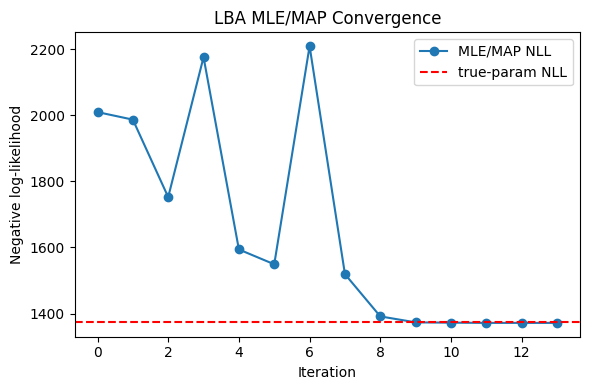

In [36]:
# A recovery
param = {'A': [2, 4, 6], 'b': 8, 'v': 1, 's': 1, 'tau': 0}
df = generate_lba_data(n_trials = 500, param = param, n_acc=3)

rt = df['rt'].to_numpy()
response = df['response'].to_numpy()

# 1) symbolic vars
rt_var   = pt.vector("rt")
resp_var = pt.ivector("resp")
A_var    = pt.vector("A")    # we’ll only optimize A here
# fix b, v, s, tau to known constants or include as more vars

# 2) build symbolic neg‐loglik
p_vec   = LBA(rt_var, resp_var, n=3,
              A=A_var, b=8, v=1, s=1, tau=0)
neglogl = -pt.sum(pt.log(p_vec + 1e-12))

# 3) get gradient
g_A = pt.grad(neglogl, A_var)

# 4) compile PyTensor function
f_and_g = pytensor.function(
    inputs=[A_var, rt_var, resp_var],
    outputs=[neglogl, g_A],
)

# 5) wrapper for SciPy
loss_hist = []

def fun_and_grad_traced(A_numpy):
    nll, grad = f_and_g(A_numpy, rt, response)
    loss_hist.append(float(nll))
    return float(nll), np.array(grad, dtype=float)

# 6) initial guess & bounds
# A0 = np.array([6.,10.,20.])
# random.seed(42)
A0 = np.random.uniform(1, 30, size=3)  # Random
bounds = [(1e-3, 30)] * 3

res = minimize(fun_and_grad_traced, A0, jac=True,
               bounds=bounds, method="L-BFGS-B")

A_true = np.array(param['A'])

print("TRUE A:", A_true)
print("MLE/MAP A:", res.x)

nll_true, _ = f_and_g(A_true, rt, response)

plt.figure(figsize=(6,4))
plt.plot(loss_hist, marker='o', linestyle='-', label="MLE/MAP NLL")
plt.axhline(nll_true, color='red', linestyle='--', label="true-param NLL")
plt.xlabel("Iteration")
plt.ylabel("Negative log-likelihood")
plt.title("LBA MLE/MAP Convergence")
plt.legend()
plt.tight_layout()
plt.show()

### b

TRUE b: [ 6. 10. 20.]
MLE/MAP b: [ 5.96022722  9.87606861 18.89519353]


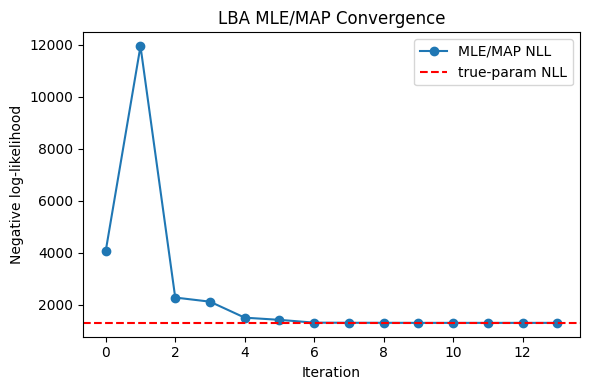

In [ ]:
# B recovery
param = {'A': 4, 'b': [6, 10, 20], 'v': 1, 's': 1, 'tau': 0}
df = generate_lba_data(n_trials = 500, param = param, n_acc=3)

rt = df['rt'].to_numpy()
response = df['response'].to_numpy()

# 1) symbolic vars
rt_var   = pt.vector("rt")
resp_var = pt.ivector("resp")
b_var    = pt.vector("b")    # we’ll only optimize b here
# fix A, v, s, tau to known constants or include as more vars

# 2) build symbolic neg‐loglik
p_vec   = LBA(rt_var, resp_var, n=3,
              A=4, b=b_var, v=1, s=1, tau=0)
neglogl = -pt.sum(pt.log(p_vec + 1e-12))

# 3) get gradient
g_b = pt.grad(neglogl, b_var)

# 4) compile PyTensor function
f_and_g = pytensor.function(
    inputs=[b_var, rt_var, resp_var],
    outputs=[neglogl, g_b],
)

# 5) wrapper for SciPy
loss_hist = []

def fun_and_grad_traced(b_numpy):
    nll, grad = f_and_g(b_numpy, rt, response)
    loss_hist.append(float(nll))
    return float(nll), np.array(grad, dtype=float)

# 6) initial guess & bounds
# b0 = np.array([6.,10.,20.])
# random.seed(42)
b0 = np.random.uniform(1, 30, size=3)  # Random
bounds = [(1e-3, 30)] * 3

res = minimize(fun_and_grad_traced, b0, jac=True,
               bounds=bounds, method="L-BFGS-B")

b_true = np.array([6., 10., 20.]) 

print("TRUE b:", b_true)
print("MLE/MAP b:", res.x)

nll_true, _ = f_and_g(b_true, rt, response)

plt.figure(figsize=(6,4))
plt.plot(loss_hist, marker='o', linestyle='-', label="MLE/MAP NLL")
plt.axhline(nll_true, color='red', linestyle='--', label="true-param NLL")
plt.xlabel("Iteration")
plt.ylabel("Negative log-likelihood")
plt.title("LBA MLE/MAP Convergence")
plt.legend()
plt.tight_layout()
plt.show()

### v

TRUE v: [1 2 3]
MLE/MAP v: [0.99374292 2.03992162 2.96473354]


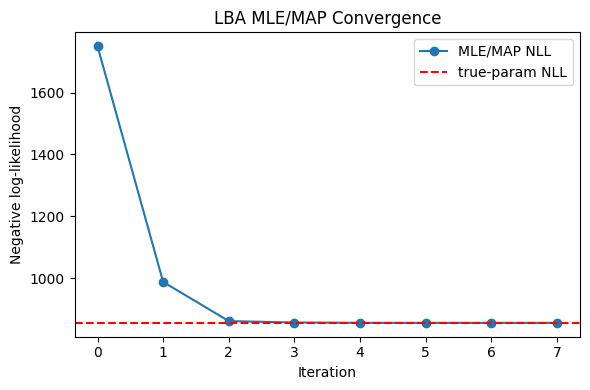

In [ ]:
# v recovery
param = {'A': 4, 'b': 8, 'v': [1, 2, 3], 's': 1, 'tau': 0}
df = generate_lba_data(n_trials = 500, param = param, n_acc=3)

rt = df['rt'].to_numpy()
response = df['response'].to_numpy()

# 1) symbolic vars
rt_var   = pt.vector("rt")
resp_var = pt.ivector("resp")
v_var    = pt.vector("v")    # we’ll only optimize v here
# fix A, v, s, tau to known constants or include as more vars

# 2) build symbolic neg‐loglik
p_vec   = LBA(rt_var, resp_var, n=3,
              A=4, b=8, v=v_var, s=1, tau=0)
neglogl = -pt.sum(pt.log(p_vec + 1e-12))

# 3) get gradient
g_v = pt.grad(neglogl, v_var)

# 4) compile PyTensor function
f_and_g = pytensor.function(
    inputs=[v_var, rt_var, resp_var],
    outputs=[neglogl, g_v],
)

# 5) wrapper for SciPy
loss_hist = []

def fun_and_grad_traced(v_numpy):
    nll, grad = f_and_g(v_numpy, rt, response)
    loss_hist.append(float(nll))
    return float(nll), np.array(grad, dtype=float)

# 6) initial guess & bounds
# v0 = np.array([6.,10.,20.])
# random.seed(42)
v0 = np.random.uniform(1, 10, size=3)  # Random
bounds = [(1e-3, 30)] * 3

res = minimize(fun_and_grad_traced, v0, jac=True,
               bounds=bounds, method="L-BFGS-B")

v_true = np.array(param['v'])

print("TRUE v:", v_true)
print("MLE/MAP v:", res.x)

nll_true, _ = f_and_g(v_true, rt, response)

plt.figure(figsize=(6,4))
plt.plot(loss_hist, marker='o', linestyle='-', label="MLE/MAP NLL")
plt.axhline(nll_true, color='red', linestyle='--', label="true-param NLL")
plt.xlabel("Iteration")
plt.ylabel("Negative log-likelihood")
plt.title("LBA MLE/MAP Convergence")
plt.legend()
plt.tight_layout()
plt.show()

### Tau

TRUE tau: [1 2 3]
MLE/MAP tau: [1.39426404 1.81963315 2.24434757]


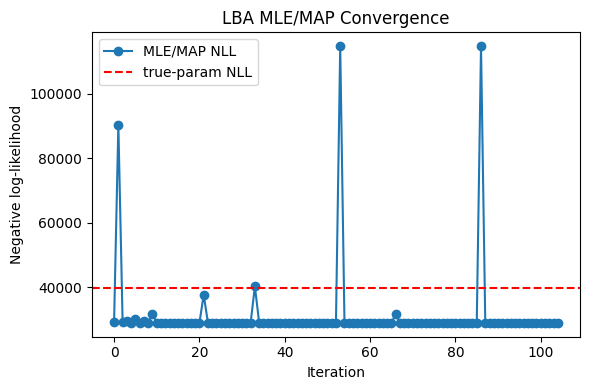

In [66]:
# tau recovery
param = {'A': 4, 'b': 8, 'v': 1, 's': 1, 'tau': [1, 2, 3]}
df = generate_lba_data(n_trials = 10000, param = param, n_acc=3)

rt = df['rt'].to_numpy()
response = df['response'].to_numpy()

# 1) symbolic vars
rt_var   = pt.vector("rt")
resp_var = pt.ivector("resp")
tau_var  = pt.vector("tau")    # we’ll only optimize tau here
# fix A, v, s, tau to known constants or include as more vars

# 2) build symbolic neg‐loglik
p_vec   = LBA(rt_var, resp_var, n=3,
              A=4, b=8, v=1, s=1, tau=tau_var)
neglogl = -pt.sum(pt.log(p_vec + 1e-12))

# 3) get gradient
g_tau = pt.grad(neglogl, tau_var)

# 4) compile PyTensor function
f_and_g = pytensor.function(
    inputs=[tau_var, rt_var, resp_var],
    outputs=[neglogl, g_tau],
)

# 5) wrapper for SciPy
loss_hist = []

def fun_and_grad_traced(tau_numpy):
    nll, grad = f_and_g(tau_numpy, rt, response)
    loss_hist.append(float(nll))
    return float(nll), np.array(grad, dtype=float)

# 6) initial guess & bounds
# v0 = np.array([6.,10.,20.])
# random.seed(42)
tau0 = np.random.uniform(1, 3, size=3)  # Random
bounds = [(1e-3, 4)] * 3

res = minimize(fun_and_grad_traced, tau0, jac=True,
               bounds=bounds, method="L-BFGS-B")

tau_true = np.array(param['tau'])

print("TRUE tau:", tau_true)
print("MLE/MAP tau:", res.x)

nll_true, _ = f_and_g(tau_true, rt, response)

plt.figure(figsize=(6,4))
plt.plot(loss_hist, marker='o', linestyle='-', label="MLE/MAP NLL")
plt.axhline(nll_true, color='red', linestyle='--', label="true-param NLL")
plt.xlabel("Iteration")
plt.ylabel("Negative log-likelihood")
plt.title("LBA MLE/MAP Convergence")
plt.legend()
plt.tight_layout()
plt.show()

TRUE tau: [1 2 3]
Best recovered tau: [1.07280692 1.75905419 2.32460068]
Best NLL: 28830.745417610986


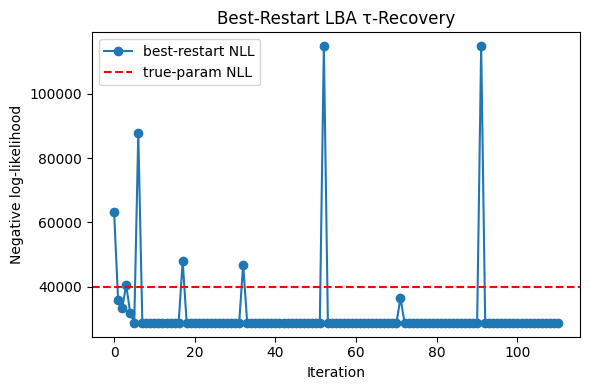

In [68]:

# tau recovery
param = {'A': 4, 'b': 8, 'v': 1, 's': 1, 'tau': [1, 2, 3]}
df = generate_lba_data(n_trials = 100000, param = param, n_acc=3)

# how many random restarts
n_restarts = 10

best = None
best_hist = None

for seed in range(n_restarts):
    # 1) draw a fresh init in [1,3]
    rng = np.random.default_rng(seed)
    tau0 = rng.uniform(1, 3, size=3)

    # 2) reset your loss‐history for this run
    loss_hist = []
    def fun_and_grad_traced(tau_numpy):
        nll, grad = f_and_g(tau_numpy, rt, response)
        loss_hist.append(float(nll))
        return float(nll), np.array(grad, dtype=float)

    # 3) run L‑BFGS‑B from this init
    res = minimize(
        fun_and_grad_traced,
        tau0,
        jac=True,
        bounds=[(1e-3, 4)]*3,
        method="L-BFGS-B"
    )

    # 4) keep the best (lowest nll)
    if best is None or res.fun < best.fun:
        best = res
        best_hist = loss_hist.copy()

# after loop: report
print("TRUE tau:", np.array(param['tau']))
print("Best recovered tau:", best.x)
print("Best NLL:", best.fun)

# plot the convergence for the best run
plt.figure(figsize=(6,4))
plt.plot(best_hist, marker='o', linestyle='-',
         label="best‐restart NLL")
nll_true, _ = f_and_g(np.array(param['tau']), rt, response)
plt.axhline(nll_true, color='red', linestyle='--',
            label="true‐param NLL")
plt.xlabel("Iteration")
plt.ylabel("Negative log‑likelihood")
plt.title("Best‐Restart LBA τ‐Recovery")
plt.legend()
plt.tight_layout()
plt.show()


## Crossvalidation

In [74]:
def crossval_lba(df, param, n_acc, eval_split=0.3, seed=None):
    """
    Cross-validate an LBA fit by optimizing exactly one 'unknown' parameter.

    Args:
        df (pd.DataFrame): must have 'rt' (float) and 'response' (int) cols.
        param (dict): e.g. {'A':4, 'b':8, 'v':'unknown', 's':1, 'tau':0}.
                      Exactly one value must be the string 'unknown'.
        n_acc (int): number of accumulators.
        eval_split (float): fraction for test set (default 0.3). If 0, use full data.
        seed (int|None): RNG seed for reproducibility.
    Returns:
        recovered_params (dict): same keys as `param`, but 'unknown' replaced
                                 by an array of length n_acc with MLEs.
        test_loglik (float): sum of log p(rt,response) on the test or full set.
    """
    # 1) Extract RT & resp arrays
    rt_all   = df['rt'].to_numpy()
    resp_all = df['response'].to_numpy()
    rng = np.random.default_rng(seed)

    # 2) Train/test split (or use full data)
    if eval_split <= 0:
        rt_train, resp_train = rt_all, resp_all
        rt_test,  resp_test  = rt_all, resp_all
    else:
        idx = rng.permutation(len(df))
        n_test = int(len(df) * eval_split)
        test_idx, train_idx = idx[:n_test], idx[n_test:]
        rt_train, resp_train = rt_all[train_idx], resp_all[train_idx]
        rt_test,  resp_test  = rt_all[test_idx],  resp_all[test_idx]

    # 3) Identify the unknown parameter
    unknowns = [k for k, v in param.items() if v == 'unknown']
    if len(unknowns) != 1:
        raise ValueError("`param` must have exactly one value=='unknown'")
    unk = unknowns[0]

    # 4) Collect fixed parameters (use LBA's internal broadcast)
    fixed = {k: param[k] for k in param if k != unk}

    # 5) PyTensor symbols
    unk_var  = pt.vector(unk)
    rt_var   = pt.vector('rt')
    resp_var = pt.ivector('resp')

    # 6) Assemble symbolic params
    sym_params = {}
    for k in ('A', 'b', 'v', 's', 'tau'):
        if k == unk:
            sym_params[k] = unk_var
        else:
            sym_params[k] = pt.constant(fixed[k])

    # 7) Define train neg-loglik + grad
    p_train       = LBA(rt_var, resp_var, n_acc, **sym_params)
    nll_train     = -pt.sum(pt.log(p_train + 1e-12))
    grad_train    = pt.grad(nll_train, unk_var)
    f_and_g_train = pytensor.function(
        [unk_var, rt_var, resp_var],
        [nll_train, grad_train]
    )

    # 8) Define test neg-loglik
    p_test     = LBA(rt_var, resp_var, n_acc, **sym_params)
    nll_test   = -pt.sum(pt.log(p_test + 1e-12))
    f_nll_test = pytensor.function([unk_var, rt_var, resp_var], nll_test)

    # 9) Optimize on training set
    x0     = rng.uniform(1, 10, size=n_acc)
    bounds = [(1e-3, 30.0)] * n_acc
    def fun_and_grad(x):
        nll, grad = f_and_g_train(x, rt_train, resp_train)
        return float(nll), np.array(grad, dtype=float)

    result  = minimize(
        fun_and_grad,
        x0,
        method='L-BFGS-B',
        jac=True,
        bounds=bounds
    )
    recovered = result.x

    # 10) Evaluate test log-likelihood
    test_nll = f_nll_test(recovered, rt_test, resp_test)
    test_ll  = float(-test_nll)

    # 11) Build recovered params dict
    recovered_params = {k: (recovered if k == unk else fixed[k])
                        for k in ('A', 'b', 'v', 's', 'tau')}

    return recovered_params, test_ll


In [75]:
# v recovery
param = {'A': 4, 'b': 8, 'v': [1, 2, 3], 's': 1, 'tau': 0}
df = generate_lba_data(n_trials = 500, param = param, n_acc=3)


In [77]:
u_param = {'A': 4, 'b': 8, 'v': 'unknown', 's': 1, 'tau': 0}
recovered_params, test_ll = crossval_lba(df, u_param, n_acc=3, eval_split=0.3, seed=42)

In [79]:
recovered_params

{'A': 4,
 'b': 8,
 'v': array([0.95697009, 1.97398495, 3.06510986]),
 's': 1,
 'tau': 0}

In [78]:
test_ll

-227.16025035386136